### Random Forest por grupo

In [12]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.append(str(REPO_ROOT))

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

from models.rfs import random_forest_from_file, load_split, INV_ENCODING

In [13]:
SPLITS = Path("../../../data/datasets/splits")
MODELS = Path("../../../data/models/rfs")
#RUN = Path("run-2026-09-20-16-04-09-utec")
#RUN = Path("run-2026-09-20-13-50-35")
#RUN = Path("run-2026-09-20-14-02-30")
RUN = Path("run-2026-09-20-14-40-11")
MODEL_PATH = MODELS / RUN
MODEL_PATH

PosixPath('../../../data/models/rfs/run-2026-09-20-14-40-11')

In [14]:
def load_random_forests():
    rfs = {}
    for p in MODEL_PATH.glob("*.joblib"):
        fname = str(p)
        grupo = fname.split("/")[-1].split(".")[0][3:]
        rf = random_forest_from_file(p)
        rfs[grupo] = rf
    return rfs

In [15]:
rfs = load_random_forests()

In [16]:
def plot_cm(y_true, y_pred, labels, target_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.show()

In [17]:
grupo = "LDS"
X_train, y_train = load_split(grupo, "train", SPLITS)
X_val, y_val = load_split(grupo, "val", SPLITS)

In [18]:
grupos = list(rfs.keys())
grupos

['RDP-MONTES', 'RN-UPM1', 'LDS', 'RN-UPM2']

In [19]:
resultados = []
predicciones = {}
for grupo in sorted(grupos):
    rf = rfs[grupo]
    X_val, y_val = load_split(grupo, "val", SPLITS)
    y_pred = rf.predict(X_val)

    labels = sorted(y_val.unique())
    accuracy = accuracy_score(y_val, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_pred, labels=labels, average="macro", zero_division=0
    )

    resultados.append({
        "grupo": grupo,
        "n_val": len(y_val),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })
    predicciones[grupo] = (y_val, y_pred, labels)

#### Resumen comparativo

In [20]:
resumen = pd.DataFrame(resultados).set_index("grupo")
resumen

,n_val,accuracy,precision,recall,f1_score
grupo,,,,,
LDS,96,0.687500,0.425926,0.365659,0.359068
RDP-MONTES,19,0.789474,0.878788,0.733333,0.755991
RN-UPM1,19,0.684211,0.514583,0.536905,0.525000
RN-UPM2,112,0.482143,0.387855,0.322673,0.333382


#### Muestras y accuracy por grupo (entrenamiento vs validacion)

In [21]:
resultados_muestras = []
for grupo in sorted(grupos):
    rf = rfs[grupo]
    X_train, y_train = load_split(grupo, "train", SPLITS)
    X_val, y_val = load_split(grupo, "val", SPLITS)

    y_train_pred = rf.predict(X_train)
    y_val_pred = rf.predict(X_val)

    resultados_muestras.append({
        "Zona/Grupo": grupo,
        "Total de muestras": len(X_train) + len(X_val),
        "Total de muestras entrenamiento": len(X_train),
        "Total de muestras validación": len(X_val),
        "Accuracy en conjunto de entrenamiento": accuracy_score(y_train, y_train_pred),
        "Accuracy en conjunto de validación": accuracy_score(y_val, y_val_pred),
    })

tabla_muestras = pd.DataFrame(resultados_muestras).set_index("Zona/Grupo")
tabla_muestras

,Total de muestras,Total de muestras entrenamiento,Total de muestras validación,Accuracy en conjunto de entrenamiento,Accuracy en conjunto de validación
Zona/Grupo,,,,,
LDS,636,540,96,0.829630,0.687500
RDP-MONTES,124,105,19,0.857143,0.789474
RN-UPM1,122,103,19,0.825243,0.684211
RN-UPM2,743,631,112,0.746434,0.482143


#### Matrices de confusion por grupo

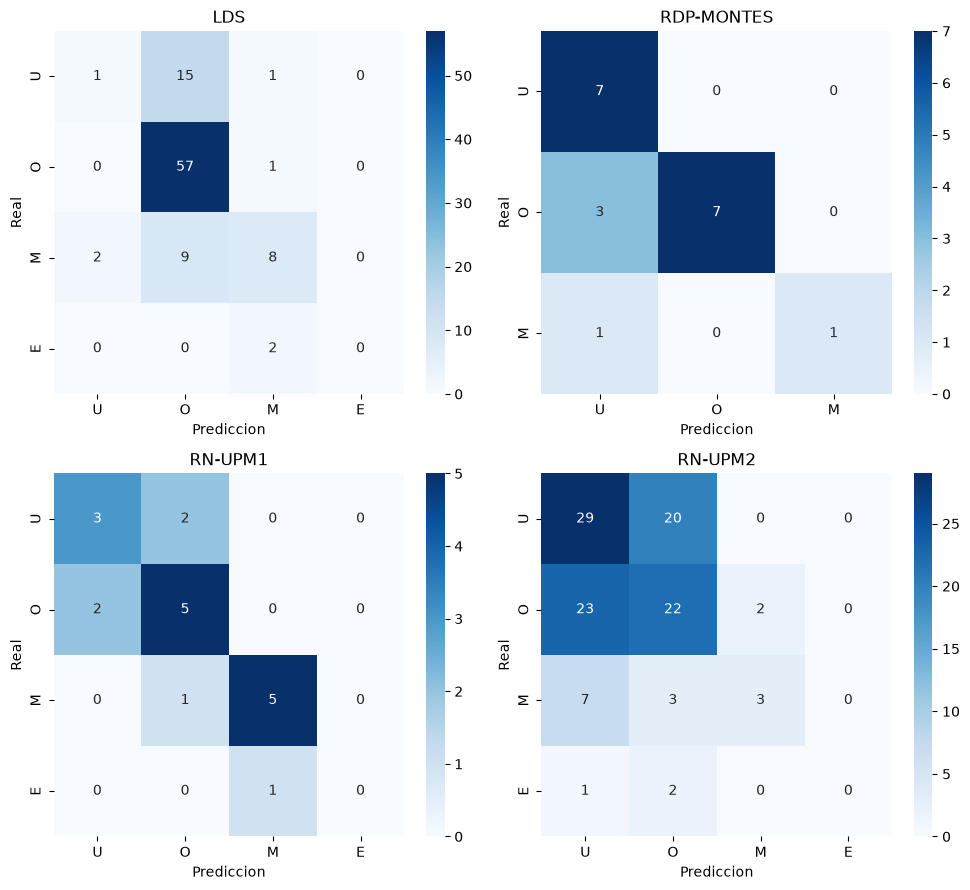

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, grupo in zip(axes.flat, sorted(predicciones.keys())):
    y_val, y_pred, labels = predicciones[grupo]
    target_names = [INV_ENCODING[c] for c in labels]
    cm = confusion_matrix(y_val, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(grupo)
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()